In [1]:
import firedrake as fd
from firedrake import inner, dx, div, sqrt, dot

In [2]:
import matplotlib.pyplot as plt
from typing import Any

In [8]:
"""
Solve the eikonal equation |grad(u)| = 1 on the unit square with zero bcs
via latent variable proximal point (LVPP).

Reference, section 5.1 in https://doi.org/10.1016/j.cma.2025.118181.

S. Dokken, P. E. Farrell, B. Keith, I. P. A. Papadopoulos, T. M. Surowiec, 
The latent variable proximal point algorithm for variational problems with inequality constraints, 
Computer Methods in Applied Mechanics and Engineering, 2025.

"""
mesh = fd.Mesh("/Users/dlilien/Projects/ISMIP7/simple_meshes/greenland_20000_2000.msh")

 

# Also works with degree=0.
degree = 1
Q = fd.FunctionSpace(mesh, "RT", degree+1)
V = fd.FunctionSpace(mesh, "DG", degree)

Z = fd.MixedFunctionSpace([V,Q])
z = fd.Function(Z)
u,psi = fd.split(z)

u_old = fd.Function(V) 
psi_old = fd.Function(Q)

z_trial = fd.TestFunction(Z)
v,w = fd.split(z_trial)

alpha = fd.Constant(1)

# See (5.5a) and (5.5b) in https://doi.org/10.1016/j.cma.2025.118181.
F = fd.inner(psi / fd.sqrt(1+fd.dot(psi,psi)), w)*fd.dx(degree=10) + fd.inner(u, fd.div(w))*fd.dx(degree=10)
F += fd.inner(fd.div(psi), v)*fd.dx(degree=10) - fd.inner(fd.div(psi_old), v)*fd.dx(degree=10) + alpha*fd.inner(fd.Constant(1), v)*fd.dx(degree=10)

bcs =  fd.DirichletBC(Z.sub(0), 0, "on_boundary")

# Use LU factorization
tol = 1e-8
sp = {
    "snes_monitor": None,
    "snes_linesearch_type": "secant",
    "snes_linesearch_damping": 0.5,
    "snes_rtol": tol,
    "snes_atol": tol,
    "snes_stol": tol,
    "snes_max_it": 100,
    "pc_factor_mat_solver_type": "mumps",
    "mat_mumps_icntl_14": 500,
    "ksp_type": "preonly",
    "pc_type": "lu",
}

NLVP = fd.NonlinearVariationalProblem(F, z, bcs=bcs)
NLVS = fd.NonlinearVariationalSolver(NLVP, solver_parameters=sp)
sp = {"snes_type": "newtontr",
    "snes_tr_delta0": 1e14,
    "snes_max_it": 500,
    "snes_monitor": None,
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
    "snes_rtol": tol,
    "snes_atol": tol,
    "snes_stol": tol,
}
NLVS2 = fd.NonlinearVariationalSolver(NLVP, solver_parameters=sp)


u, psi = z.subfunctions
out = fd.VTKFile("out/eikonal.pvd")
alpha.assign(1)
u.assign(0)

lvpp_max_its = 40 # max LVPP iterates
for k in range(lvpp_max_its):
    print(f"alpha = {float(alpha)}")
    u_old.assign(u)

    try:
        NLVS2.solve() # solve the LVPP subproblem
    except fd.ConvergenceError:
        u.assign(u_old)
        psi.assign(psi_old)
        print("Cannot do better")
        break
    psi_old.assign(psi) # update the previous latent variable

    out.write(u) # save current iterate to disk
    
    # break if ||u^k - u^{k-1}||_{L^2} <= 1e-4
    nrm = fd.norm(u-u_old, "L2")
    print("LVPP it: %s, Cauchy Error: %s\n"%(k,nrm))
    if nrm < 1e-4:
        break

    # update rule for proximal parameter alpha
    if float(alpha) < 150:
        alpha.assign(fd.sqrt(2)*alpha)

alpha = 1.0
  0 SNES Function norm 7.574450910965e+09
  1 SNES Function norm 7.572867661149e+09
  2 SNES Function norm 7.503735805645e+09
  3 SNES Function norm 7.366092451054e+09
  4 SNES Function norm 7.097036907718e+09
  5 SNES Function norm 6.836460187796e+09
  6 SNES Function norm 6.583860985776e+09
  7 SNES Function norm 6.339632601472e+09
  8 SNES Function norm 6.103610395261e+09
  9 SNES Function norm 5.875445386914e+09
 10 SNES Function norm 5.654756201804e+09
 11 SNES Function norm 5.441171347177e+09
 12 SNES Function norm 5.234321676105e+09
 13 SNES Function norm 5.033710367373e+09
 14 SNES Function norm 4.838578234360e+09
 15 SNES Function norm 4.648417987374e+09
 16 SNES Function norm 4.462699214207e+09
 17 SNES Function norm 4.280816387428e+09
 18 SNES Function norm 4.102317866029e+09
 19 SNES Function norm 3.927231649266e+09
 20 SNES Function norm 3.755353248810e+09
 21 SNES Function norm 3.586338293943e+09
 22 SNES Function norm 3.420297506620e+09
 23 SNES Function norm

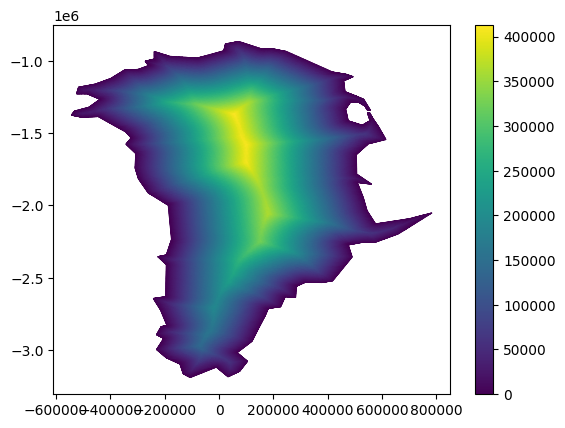

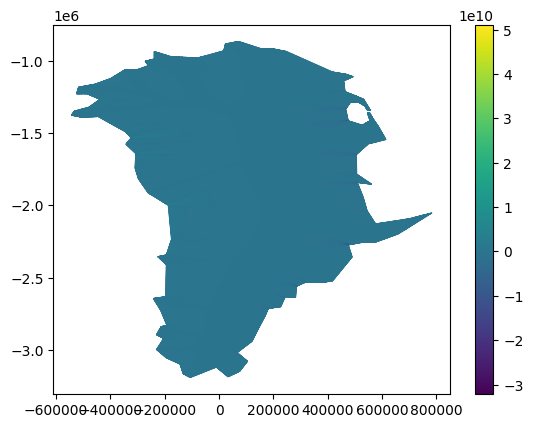

In [9]:
cm = fd.tripcolor(u)
plt.colorbar(cm)

cm = fd.tripcolor(fd.assemble(fd.Function(V).interpolate(psi[0])))
plt.colorbar(cm)